# Main Quest 01 GPT-1 구현

**개선 방향**: Encoder-Decoder Transformer → GPT-1 (Decoder-Only) 구조로 전환

---

## 주요 변경점

| 항목 | Ex08 (Transformer Chatbot) | 이번 구현 (GPT-1) |
|------|---------------------------|--------------------|
| **구조** | Encoder + Decoder (Seq2Seq) | Decoder-Only (단일 스택) |
| **Attention** | PyTorch `nn.Transformer` 내장 사용 | **직접 구현한 `MultiHeadSelfAttention`** 사용 |
| **Positional Encoding** | Sinusoidal (고정) | Learnable Positional Embedding (학습 가능) |
| **입력 형식** | Q, A 분리 입력 | `[BOS] Q [SEP] A [EOS]` 단일 시퀀스 |
| **Cross-Attention** | 있음 (Encoder→Decoder) | 없음 (Self-Attention만) |
| **Layer Norm 위치** | Post-LN | Pre-LN (GPT-1 스타일) |
| **파라미터 공유** | Src/Tgt Embedding 분리 | 단일 Token Embedding + Output Weight Tying |

### 설계 원칙
- MultiHeadSelfAttention은 **프레임워크 내장 사용 없이 직접 구현**
- Causal (Autoregressive) Mask를 통해 강제로 미래 토큰을 보지 못하도록 함
- GPT-1 논문 기준: 12-layer, 768-dim, 12-head → 실험용 소형(4-layer, 256-dim, 8-head)으로 조정

## 1. 라이브러리 및 환경 설정

In [1]:
! pip install sentencepiece

import torch
print('PyTorch version:', torch.__version__)

import os, re, math, time
import pandas as pd
import numpy as np
import sentencepiece as spm
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print('모든 라이브러리 임포트 완료')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 8.8 MB/s eta 0:00:00a 0:00:01
PyTorch version: 2.7.1+cu118
모든 라이브러리 임포트 완료


## 2. 데이터 수집

In [2]:
DATA_PATH = os.path.expanduser('~/work/gpt1_chatbot/data/ChatbotData.csv')
MODEL_DIR = os.path.expanduser('~/work/gpt1_chatbot/')

os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

if not os.path.exists(DATA_PATH):
    import urllib.request
    url = 'https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv'
    print('ChatbotData.csv 다운로드 중...')
    urllib.request.urlretrieve(url, DATA_PATH)
    print('다운로드 완료!')
else:
    print('기존 파일 사용:', DATA_PATH)

df = pd.read_csv(DATA_PATH)
print('데이터 형태:', df.shape)
print('컬럼:', df.columns.tolist())
df.head()

기존 파일 사용: /home/jovyan/work/gpt1_chatbot/data/ChatbotData.csv
데이터 형태: (11823, 3)
컬럼: ['Q', 'A', 'label']


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


## 3. 데이터 전처리

### GPT-1과 Ex08의 차이점
Ex08은 Q와 A를 **별도의 시퀀스**로 처리(Encoder/Decoder 분리)했지만,  
GPT-1은 **단일 시퀀스**로 이어붙여서 처리합니다.

```
Ex08:  src = [BOS] Q [EOS]   |   tgt = [BOS] A [EOS]
GPT-1: seq = [BOS] Q [SEP] A [EOS]   (하나의 시퀀스)
```

GPT-1 논문(Radford et al., 2018)에서 fine-tuning 시 delimiter token을 삽입하는 방식을 채용합니다.

In [3]:
def preprocess_korean(text: str) -> str:
    """한국어 텍스트 전처리 (Ex08과 동일 유지)"""
    text = str(text).strip()
    text = re.sub(r'[^가-힣a-zA-Z0-9\s.,!?~]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Q'] = df['Q'].apply(preprocess_korean)
df['A'] = df['A'].apply(preprocess_korean)

# 빈 행 제거
df = df[(df['Q'].str.len() > 0) & (df['A'].str.len() > 0)].reset_index(drop=True)
print(f'전처리 후 데이터 수: {len(df):,}')
df[['Q', 'A']].head(10)

전처리 후 데이터 수: 11,823


,Q,A
0,12시 땡!,하루가 또 가네요.
1,1지망 학교 떨어졌어,위로해 드립니다.
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.
4,PPL 심하네,눈살이 찌푸려지죠.
5,SD카드 망가졌어,다시 새로 사는 게 마음 편해요.
6,SD카드 안돼,다시 새로 사는 게 마음 편해요.
7,SNS 맞팔 왜 안하지,잘 모르고 있을 수도 있어요.
8,SNS 시간낭비인 거 아는데 매일 하는 중,시간을 정하고 해보세요.
9,SNS 시간낭비인데 자꾸 보게됨,시간을 정하고 해보세요.


In [4]:
# SentencePiece 훈련용 말뭉치 저장
# [SEP] 특수 토큰을 위해 user_defined_symbols에 추가
corpus_path = os.path.join(MODEL_DIR, 'corpus.txt')
with open(corpus_path, 'w', encoding='utf-8') as f:
    for q, a in zip(df['Q'], df['A']):
        f.write(q + '\n')
        f.write(a + '\n')
print(f'말뭉치 저장 완료: {corpus_path}')
print(f'총 문장 수: {len(df)*2:,}')

말뭉치 저장 완료: /home/jovyan/work/gpt1_chatbot/corpus.txt
총 문장 수: 23,646


## 4. SentencePiece BPE 토크나이저

Ex08 대비 추가: `[SEP]` 토큰 (Q와 A를 구분하는 구분자)

In [5]:
SPM_PREFIX = os.path.join(MODEL_DIR, 'gpt1_spm')
VOCAB_SIZE  = 8000

if not os.path.exists(SPM_PREFIX + '.model'):
    spm.SentencePieceTrainer.train(
        input=corpus_path,
        model_prefix=SPM_PREFIX,
        vocab_size=VOCAB_SIZE,
        model_type='bpe',
        pad_id=0,  pad_piece='<pad>',
        unk_id=1,  unk_piece='<unk>',
        bos_id=2,  bos_piece='<s>',
        eos_id=3,  eos_piece='</s>',
        # GPT-1용 추가: [SEP] 구분자 토큰
        user_defined_symbols=['[SEP]'],
        character_coverage=0.9995,
    )
    print('SentencePiece 모델 훈련 완료')
else:
    print('기존 SentencePiece 모델 로드')

sp = spm.SentencePieceProcessor()
sp.load(SPM_PREFIX + '.model')

PAD_IDX = sp.piece_to_id('<pad>')    # 0
BOS_IDX = sp.piece_to_id('<s>')      # 2
EOS_IDX = sp.piece_to_id('</s>')     # 3
SEP_IDX = sp.piece_to_id('[SEP]')    # GPT-1용 구분자
print(f'PAD={PAD_IDX}, BOS={BOS_IDX}, EOS={EOS_IDX}, SEP={SEP_IDX}')

기존 SentencePiece 모델 로드
PAD=0, BOS=2, EOS=3, SEP=4


## 5-A. GPT-1 Dataset & DataLoader

### 변경 사항: 입력 형식

GPT-1은 Language Model이므로 **다음 토큰 예측**을 학습합니다.

```
입력 시퀀스: [BOS] Q_tokens [SEP] A_tokens [EOS]
학습 목표:    Q_tokens [SEP] A_tokens [EOS] (한 칸씩 shift된 정답)
```

Loss는 **SEP 이후 A 부분에서만** 계산합니다 (질문 부분 예측은 학습 signal에서 제외).

In [6]:
MAX_LEN    = 80   # Q + SEP + A를 담기 위해 Ex08(40)보다 확장
BATCH_SIZE = 64


class GPT1ChatDataset(Dataset):
    """
    GPT-1 스타일 데이터셋
    
    시퀀스 구조:
        [BOS] Q_tokens [SEP] A_tokens [EOS] + [PAD] ...
    
    Labels:
        input_ids를 1칸 shift한 next-token prediction 라벨
        Q 구간 라벨은 -100(ignore)으로 마스킹 → A 부분만 학습
    """

    def __init__(self, questions, answers, max_len=MAX_LEN):
        self.samples = []
        for q, a in zip(questions, answers):
            q_ids = sp.encode(q, out_type=int)
            a_ids = sp.encode(a, out_type=int)

            # [BOS] Q [SEP] A [EOS] 로 이어붙이기
            full = [BOS_IDX] + q_ids + [SEP_IDX] + a_ids + [EOS_IDX]

            # max_len 맞추기 (자르기 + 패딩)
            full = full[:max_len]
            sep_pos = full.index(SEP_IDX) if SEP_IDX in full else len(full)

            input_ids = full + [PAD_IDX] * (max_len - len(full))

            # Labels: input_ids를 1칸 왼쪽으로 shift (next-token prediction)
            labels = input_ids[1:] + [PAD_IDX]

            # Q 구간([BOS]~[SEP])은 -100으로 마스킹 → A 예측에만 집중
            for i in range(sep_pos + 1):   # BOS ~ SEP 위치까지 ignore
                if i < len(labels):
                    labels[i] = -100
            # PAD 위치도 ignore
            for i in range(len(labels)):
                if input_ids[i] == PAD_IDX:
                    labels[i] = -100

            self.samples.append((input_ids, labels))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        input_ids, labels = self.samples[idx]
        return (
            torch.tensor(input_ids, dtype=torch.long),
            torch.tensor(labels,    dtype=torch.long),
        )


split = int(len(df) * 0.9)
train_ds = GPT1ChatDataset(df['Q'][:split].tolist(), df['A'][:split].tolist())
valid_ds = GPT1ChatDataset(df['Q'][split:].tolist(), df['A'][split:].tolist())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f'학습 샘플: {len(train_ds):,} | 검증 샘플: {len(valid_ds):,}')
print(f'학습 배치: {len(train_loader)} | 검증 배치: {len(valid_loader)}')

# 샘플 확인
sample_ids, sample_labels = train_ds[0]
print('\n[샘플 시퀀스 확인]')
print('input_ids:', sample_ids[:20].tolist())
print('labels   :', sample_labels[:20].tolist())

학습 샘플: 10,640 | 검증 샘플: 1,183
학습 배치: 166 | 검증 배치: 19

[샘플 시퀀스 확인]
input_ids: [2, 5559, 6966, 3204, 7072, 4, 4484, 212, 5929, 6925, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0]
labels   : [-100, -100, -100, -100, -100, -100, 212, 5929, 6925, 3, 0, -100, -100, -100, -100, -100, -100, -100, -100, -100]


## 5-B. GPT-1 모델 구현

### MultiHeadSelfAttention

Ex08에서는 `nn.Transformer`를 사용해서 내부 Attention이 PyTorch 내장이었습니다.  
여기서는 **Scaled Dot-Product Attention + Multi-Head 분할**을 처음부터 구현합니다.

```
Attention(Q, K, V) = softmax(QKᵀ / √d_k) · V

MultiHead(Q, K, V) = Concat(head_1, ..., head_h) · W_O
  where head_i = Attention(Q·W_Q_i, K·W_K_i, V·W_V_i)
```

GPT-1은 **Self-Attention** (Q=K=V=입력) + **Causal Mask** (미래 토큰 차단) 를 사용합니다.

In [7]:
# ─────────────────────────────────────────────────────────────────
#  ① MultiHeadSelfAttention — 구현 (프레임워크 내장 미사용)
# ─────────────────────────────────────────────────────────────────
class MultiHeadSelfAttention(nn.Module):
    """
    GPT-1 스타일 Masked Multi-Head Self-Attention

    - nn.MultiheadAttention 미사용, 순수 행렬 연산으로 직접 구현
    - Causal(인과적) Masking: 위치 i에서 j>i인 미래 토큰을 -inf 처리
    - d_model을 num_heads개의 헤드로 분할하여 병렬 attention 수행

    Args:
        d_model   : 전체 임베딩 차원
        num_heads : 헤드 수 (d_model이 num_heads로 나누어 떨어져야 함)
        dropout   : Attention weight에 적용할 dropout 비율
    """

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model은 num_heads의 배수여야 합니다'

        self.d_model   = d_model
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads   # 헤드별 차원

        # Q, K, V 선형 변환 (각각 분리)
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)

        # Output 선형 변환
        self.W_O = nn.Linear(d_model, d_model, bias=False)

        self.attn_dropout = nn.Dropout(dropout)

    def scaled_dot_product_attention(
        self,
        Q: torch.Tensor,      # (batch, heads, seq, d_k)
        K: torch.Tensor,      # (batch, heads, seq, d_k)
        V: torch.Tensor,      # (batch, heads, seq, d_k)
        causal_mask: torch.Tensor,  # (seq, seq) bool — True면 -inf
        key_pad_mask: torch.Tensor  # (batch, seq) bool — True면 -inf
    ) -> torch.Tensor:
        """
        Scaled Dot-Product Attention 직접 계산
        
        Returns:
            출력 텐서 (batch, heads, seq, d_k)
        """
        scale = math.sqrt(self.d_k)

        # 1. Attention Score: QKᵀ / √d_k  →  (batch, heads, seq_q, seq_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / scale

        # 2. Causal Mask 적용 (상삼각 행렬 → 미래 위치 -inf)
        #    causal_mask: (seq, seq), True인 위치를 -inf 처리
        scores = scores.masked_fill(causal_mask.unsqueeze(0).unsqueeze(0), float('-inf'))

        # 3. Padding Mask 적용  →  (batch, 1, 1, seq_k)
        scores = scores.masked_fill(key_pad_mask.unsqueeze(1).unsqueeze(2), float('-inf'))

        # 4. Softmax → Attention Weight
        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)

        # 5. Value 가중합  →  (batch, heads, seq, d_k)
        return torch.matmul(attn_weights, V)

    def split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """(batch, seq, d_model) → (batch, heads, seq, d_k)"""
        B, T, _ = x.shape
        return x.view(B, T, self.num_heads, self.d_k).transpose(1, 2)

    def merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        """(batch, heads, seq, d_k) → (batch, seq, d_model)"""
        B, _, T, _ = x.shape
        return x.transpose(1, 2).contiguous().view(B, T, self.d_model)

    def forward(
        self,
        x: torch.Tensor,             # (batch, seq, d_model)
        causal_mask: torch.Tensor,   # (seq, seq)
        key_pad_mask: torch.Tensor,  # (batch, seq)
    ) -> torch.Tensor:
        # 1. Q, K, V 선형 변환
        Q = self.split_heads(self.W_Q(x))  # (B, heads, T, d_k)
        K = self.split_heads(self.W_K(x))
        V = self.split_heads(self.W_V(x))

        # 2. Scaled Dot-Product Attention (causal + padding mask 포함)
        attn_out = self.scaled_dot_product_attention(Q, K, V, causal_mask, key_pad_mask)

        # 3. 헤드 합치기 후 Output 투영
        return self.W_O(self.merge_heads(attn_out))

In [8]:
# ─────────────────────────────────────────────────────────────────
#  ② Feed-Forward Network
# ─────────────────────────────────────────────────────────────────
class FeedForward(nn.Module):
    """
    GPT-1 Position-wise Feed-Forward Network
    
    FFN(x) = GELU(xW_1 + b_1)W_2 + b_2
    
    GPT-1 논문은 ReLU 대신 GELU 활성화 함수를 사용합니다.
    """

    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),             # GPT-1은 GELU 사용 (Ex08의 ReLU와 다름)
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [9]:
# ─────────────────────────────────────────────────────────────────
#  ③ GPT-1 Transformer Block (Decoder Block)
# ─────────────────────────────────────────────────────────────────
class GPT1Block(nn.Module):
    """
    GPT-1 Transformer Block
    
    구조 (Pre-LN 방식):
        x → LayerNorm → MultiHeadSelfAttention → residual
          → LayerNorm → FeedForward             → residual
    
    Ex08 Transformer와 달리:
        - Cross-Attention 없음 (Self-Attention만)
        - Layer Norm이 Attention 앞에 적용 (Pre-LN, 학습 안정성 향상)
    """

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()

        # Pre-LayerNorm
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

        # 직접 구현한 Multi-Head Self-Attention (프레임워크 내장 미사용)
        self.attn = MultiHeadSelfAttention(d_model, num_heads, dropout)

        # Position-wise FFN
        self.ffn  = FeedForward(d_model, d_ff, dropout)

    def forward(
        self,
        x: torch.Tensor,             # (batch, seq, d_model)
        causal_mask: torch.Tensor,   # (seq, seq)
        key_pad_mask: torch.Tensor,  # (batch, seq)
    ) -> torch.Tensor:
        # 1. Pre-LN → Self-Attention → Residual
        x = x + self.attn(self.ln1(x), causal_mask, key_pad_mask)
        # 2. Pre-LN → FFN → Residual
        x = x + self.ffn(self.ln2(x))
        return x

In [10]:
# ─────────────────────────────────────────────────────────────────
#  ④ GPT-1 전체 모델
# ─────────────────────────────────────────────────────────────────
class GPT1(nn.Module):
    """
    GPT-1 (Generative Pre-trained Transformer)
    
    Radford et al., 2018 「Improving Language Understanding by Generative Pre-Training」
    
    Ex08 대비 주요 변경:
        1. Encoder 제거 → Decoder Stack만 사용
        2. Sinusoidal PE → Learnable Positional Embedding
        3. nn.Transformer 미사용 → 직접 구현한 GPT1Block 스택
        4. Weight Tying: 입력 Embedding과 출력 Linear의 가중치 공유
        5. 최종 Layer Norm 추가 (Pre-LN 구조의 마무리)

    Args:
        vocab_size  : 어휘 크기
        max_len     : 최대 시퀀스 길이
        d_model     : 임베딩 차원 (논문: 768, 여기서는 소형 256)
        num_heads   : 어텐션 헤드 수 (논문: 12, 여기서는 8)
        num_layers  : Transformer Block 수 (논문: 12, 여기서는 4)
        d_ff        : FFN 내부 차원 (보통 4 × d_model)
        dropout     : 드롭아웃 비율
    """

    def __init__(
        self,
        vocab_size: int,
        max_len:    int   = MAX_LEN,
        d_model:    int   = 256,
        num_heads:  int   = 8,
        num_layers: int   = 4,
        d_ff:       int   = 1024,
        dropout:    float = 0.1,
    ):
        super().__init__()

        self.d_model    = d_model
        self.max_len    = max_len
        self.num_layers = num_layers

        # ── 입력 블록 ──────────────────────────────────────────────
        # Token Embedding
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)

        # Learnable Positional Embedding (GPT-1의 핵심 특징)
        # Ex08은 Sinusoidal(고정)이었으나, GPT-1은 위치도 학습 가능한 파라미터
        self.pos_emb   = nn.Embedding(max_len, d_model)

        self.emb_drop  = nn.Dropout(dropout)

        # ── Transformer Block 스택 ─────────────────────────────────
        # 직접 구현한 GPT1Block을 num_layers개 쌓음
        self.blocks = nn.ModuleList([
            GPT1Block(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        # 최종 Layer Norm (Pre-LN 구조 마무리)
        self.ln_f = nn.LayerNorm(d_model)

        # ── 출력 헤드 ──────────────────────────────────────────────
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        # Weight Tying: 입력 Embedding = 출력 Linear 가중치 공유
        # 파라미터 수를 줄이고 표현 일관성을 높이는 GPT-1 기법
        self.lm_head.weight = self.token_emb.weight

        # 파라미터 초기화
        self._init_weights()

    def _init_weights(self):
        """GPT-1 논문 스타일 초기화"""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def make_causal_mask(self, seq_len: int, device: torch.device) -> torch.Tensor:
        """
        Causal (인과적) Mask 생성
        상삼각 행렬: 위치 i에서 j > i인 미래 토큰을 볼 수 없도록 True 설정
        """
        return torch.triu(
            torch.ones(seq_len, seq_len, device=device, dtype=torch.bool),
            diagonal=1
        )

    def forward(
        self,
        input_ids: torch.Tensor,  # (batch, seq)
    ) -> torch.Tensor:            # (batch, seq, vocab_size)

        B, T = input_ids.shape
        device = input_ids.device

        # ── 입력 블록 구성 ─────────────────────────────────────────
        # 1. Token Embedding: 각 토큰 ID → 벡터
        tok_emb = self.token_emb(input_ids)                          # (B, T, d_model)

        # 2. Learnable Positional Embedding: 위치 정보 학습
        positions = torch.arange(T, device=device).unsqueeze(0)      # (1, T)
        pos_emb   = self.pos_emb(positions)                          # (1, T, d_model)

        # 3. 두 임베딩 합산 → Dropout
        x = self.emb_drop(tok_emb + pos_emb)                        # (B, T, d_model)

        # ── Mask 생성 ──────────────────────────────────────────────
        causal_mask  = self.make_causal_mask(T, device)              # (T, T)
        key_pad_mask = (input_ids == PAD_IDX)                        # (B, T)

        # ── Transformer Blocks ─────────────────────────────────────
        for block in self.blocks:
            x = block(x, causal_mask, key_pad_mask)

        # ── 출력 ───────────────────────────────────────────────────
        x = self.ln_f(x)                    # 최종 LayerNorm
        logits = self.lm_head(x)            # (B, T, vocab_size)
        return logits


# ── 모델 인스턴스 생성 및 확인 ────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GPT1(
    vocab_size  = VOCAB_SIZE,
    max_len     = MAX_LEN,
    d_model     = 512,
    num_heads   = 8,
    num_layers  = 6,
    d_ff        = 2048,
    dropout     = 0.1,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Device         : {DEVICE}')
print(f'총 파라미터    : {total_params:,}')
print(f'학습 파라미터  : {trainable_params:,}')
print()
print('── 모델 구조 ──')
print(model)

Device         : cuda
총 파라미터    : 23,040,000
학습 파라미터  : 23,040,000

── 모델 구조 ──
GPT1(
  (token_emb): Embedding(8000, 512, padding_idx=0)
  (pos_emb): Embedding(80, 512)
  (emb_drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x GPT1Block(
      (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (W_Q): Linear(in_features=512, out_features=512, bias=False)
        (W_K): Linear(in_features=512, out_features=512, bias=False)
        (W_V): Linear(in_features=512, out_features=512, bias=False)
        (W_O): Linear(in_features=512, out_features=512, bias=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=512, out_features=2048, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linea

## 5-C. 학습 설정

In [11]:
EPOCHS    = 100
CLIP      = 1.0
CKPT_PATH = os.path.join(MODEL_DIR, 'gpt1_best.pt')

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    betas=(0.9, 0.95),
    weight_decay=0.1,   # GPT-1 정규화: Weight Decay
)

# CrossEntropyLoss: ignore_index=-100 (Q 구간 + PAD 제외)
criterion = nn.CrossEntropyLoss(ignore_index=-100, label_smoothing=0.1)

# Cosine Annealing with Linear Warmup 스케줄러
def get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps):
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))
        progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

total_steps  = EPOCHS * len(train_loader)
warmup_steps = total_steps // 10   # 전체의 10%를 warmup

scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
print(f'총 스텝: {total_steps:,} | Warmup 스텝: {warmup_steps:,}')
print('학습 설정 완료')

총 스텝: 16,600 | Warmup 스텝: 1,660
학습 설정 완료


## 5-D. 학습 & 검증 함수

In [12]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device, clip):
    model.train()
    total_loss = 0
    for input_ids, labels in loader:
        input_ids = input_ids.to(device)   # (B, T)
        labels    = labels.to(device)       # (B, T) — -100은 무시

        logits = model(input_ids)           # (B, T, V)

        # Loss: (B*T, V) vs (B*T,)
        loss = criterion(
            logits.view(-1, VOCAB_SIZE),
            labels.view(-1),
        )

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for input_ids, labels in loader:
            input_ids = input_ids.to(device)
            labels    = labels.to(device)
            logits    = model(input_ids)
            loss      = criterion(logits.view(-1, VOCAB_SIZE), labels.view(-1))
            total_loss += loss.item()
    return total_loss / len(loader)


print('학습 / 검증 함수 정의 완료')

학습 / 검증 함수 정의 완료


## 5-E. 모델 학습

In [13]:
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss  = train_epoch(model, train_loader, optimizer, scheduler,
                           criterion, DEVICE, CLIP)
    val_loss = eval_epoch(model, valid_loader, criterion, DEVICE)
    elapsed  = time.time() - t0

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    mark = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CKPT_PATH)
        mark = '  ← 저장'

    print(f'[{epoch:02d}/{EPOCHS}]  '
          f'Train: {tr_loss:.4f} | Val: {val_loss:.4f} | '
          f'PPL: {math.exp(min(val_loss, 20)):.2f} | '
          f'{elapsed:.1f}s{mark}')

print(f'\n학습 완료.  최적 Val Loss: {best_val_loss:.4f}')

[01/100]  Train: 6.7095 | Val: 5.8313 | PPL: 340.79 | 37.9s  ← 저장
[02/100]  Train: 5.2599 | Val: 5.3922 | PPL: 219.68 | 40.7s  ← 저장
[03/100]  Train: 4.9225 | Val: 5.2103 | PPL: 183.15 | 40.1s  ← 저장
[04/100]  Train: 4.6909 | Val: 5.1075 | PPL: 165.26 | 40.2s  ← 저장
[05/100]  Train: 4.4439 | Val: 5.0238 | PPL: 151.99 | 40.3s  ← 저장
[06/100]  Train: 4.1613 | Val: 4.9529 | PPL: 141.58 | 40.3s  ← 저장
[07/100]  Train: 3.8646 | Val: 4.9119 | PPL: 135.89 | 40.2s  ← 저장
[08/100]  Train: 3.5573 | Val: 4.8685 | PPL: 130.13 | 40.2s  ← 저장
[09/100]  Train: 3.2464 | Val: 4.8719 | PPL: 130.57 | 40.2s
[10/100]  Train: 2.9409 | Val: 4.8826 | PPL: 131.98 | 40.4s
[11/100]  Train: 2.6345 | Val: 4.8921 | PPL: 133.23 | 40.2s
[12/100]  Train: 2.3387 | Val: 4.9313 | PPL: 138.56 | 40.2s
[13/100]  Train: 2.0888 | Val: 4.9816 | PPL: 145.70 | 40.2s
[14/100]  Train: 1.8855 | Val: 4.9742 | PPL: 144.63 | 40.3s
[15/100]  Train: 1.7264 | Val: 5.0317 | PPL: 153.19 | 40.2s
[16/100]  Train: 1.6128 | Val: 5.0590 | PPL: 157.44 

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
/tmp/ipykernel_144/857953644.py:13: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_144/857953644.py:13: UserWarning: Glyph 4984

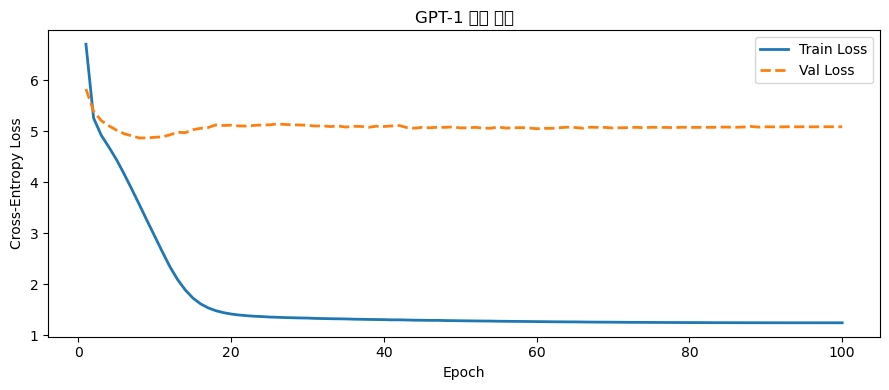

In [14]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_losses,   label='Val Loss',   linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('GPT-1 학습 곡선')
plt.legend()
plt.tight_layout()
plt.show()

## 6. 모델 평가 — 텍스트 생성

GPT-1은 Autoregressive 생성 모델입니다.

```
[BOS] Q [SEP] → 모델에 입력
               → A의 첫 토큰 예측
               → 예측 토큰 추가 후 다시 입력
               → [EOS] 또는 max_len까지 반복
```

Top-p (Nucleus) Sampling을 지원하여 다양한 응답 생성이 가능합니다.

In [15]:
# 최적 모델 로드
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()
print('최적 모델 로드 완료')


def generate(
    question:    str,
    max_new:     int   = 40,
    temperature: float = 0.8,
    top_p:       float = 0.9,
) -> str:
    question = preprocess_korean(question)

    q_ids = sp.encode(question, out_type=int)
    prompt = [BOS_IDX] + q_ids + [SEP_IDX]

    if len(prompt) >= MAX_LEN:
        prompt = prompt[:MAX_LEN - 1]

    input_ids = torch.tensor([prompt], dtype=torch.long).to(DEVICE)

    generated = []

    with torch.no_grad():
        for _ in range(max_new):
            logits      = model(input_ids)
            next_logits = logits[0, -1, :] / temperature

            # Top-p (Nucleus) Sampling
            sorted_logits, sorted_idx = torch.sort(next_logits, descending=True)
            cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)

            sorted_indices_to_remove = cumulative_probs - F.softmax(sorted_logits, dim=-1) >= top_p
            sorted_logits[sorted_indices_to_remove] = float('-inf')
            next_logits = torch.zeros_like(next_logits).scatter_(0, sorted_idx, sorted_logits)

            if torch.isinf(next_logits).all():
                next_logits = torch.zeros_like(next_logits)

            probs   = F.softmax(next_logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()

            if next_id == EOS_IDX:
                break
            if next_id in (PAD_IDX, BOS_IDX, SEP_IDX):
                continue

            generated.append(next_id)

            next_tensor = torch.tensor([[next_id]], dtype=torch.long).to(DEVICE)
            input_ids   = torch.cat([input_ids, next_tensor], dim=1)

            if input_ids.size(1) >= MAX_LEN:
                break

    return sp.decode(generated) if generated else '(응답 없음)'

최적 모델 로드 완료


## 챗봇 데모

In [16]:
test_questions = [
    '오늘 기분이 어때?',
    '나 요즘 너무 힘들어',
    '배가 고파',
    '사랑이 뭐야?',
    '친구가 없어서 외로워',
    '날씨가 좋네',
    '고마워',
    '나 취업했어!',
]

print('=' * 55)
print('         GPT-1 기반 한국어 챗봇 데모')
print('=' * 55)
for q in test_questions:
    a = generate(q, temperature=0.8, top_p=0.9)
    print(f'Q: {q}')
    print(f'A: {a}')
    print('-' * 45)

         GPT-1 기반 한국어 챗봇 데모
Q: 오늘 기분이 어때?
A: .
---------------------------------------------
Q: 나 요즘 너무 힘들어
A: .
---------------------------------------------
Q: 배가 고파
A: !
---------------------------------------------
Q: 사랑이 뭐야?
A: .
---------------------------------------------
Q: 친구가 없어서 외로워
A: .
---------------------------------------------
Q: 날씨가 좋네
A: .
---------------------------------------------
Q: 고마워
A: .
---------------------------------------------
Q: 나 취업했어!
A: .
---------------------------------------------


In [ ]:
# 대화형 챗봇 (인터랙티브 모드)
print('대화를 시작합니다. 종료하려면 "quit" 또는 "종료"를 입력하세요.')
while True:
    user_input = input('나: ').strip()
    if user_input.lower() in ('quit', '종료', 'exit', 'q'):
        print('대화를 종료합니다.')
        break
    if not user_input:
        continue
    print(f'챗봇: {generate(user_input)}\n')

대화를 시작합니다. 종료하려면 "quit" 또는 "종료"를 입력하세요.


### 마무리하며...
##### 결과는 최종 Val Loss 5점 초반, 최종 PPL 약 160 이상 + 챗봇 응답 품질불량 (단답, 문맥 불일치)으로 나왔다.
##### 챗봇 응답 예시:
##### Q: 안녕        → A: !
##### Q: 넌 누구니?  → A: 만날 수 있으면 힘들겠죠.
##### Q: 배가 고파   → A: !

##### 예상 원인 분석
##### 1. 데이터 부족
##### Epoch 부족: Epoch 30 → 100으로 늘렸지만 Val Loss가 개선되지 않았다. 이는 단순히 학습을 더 돌리는 것으로는 해결되지 않는 구조적 문제임을 시사한다.
모델 용량 미스매치: d_model=256→512, num_layers=4→6으로 키웠지만 효과가 없었다. 오히려 11,000쌍의 소규모 데이터에서는 모델이 커질수록 데이터 대비 파라미터가 과잉되어 학습이 수렴하지 않을 수 있다.
GPT 구조의 근본적 한계: GPT-1은 대규모 코퍼스로 사전학습(Pre-training) 후 챗봇 데이터로 파인튜닝하는 구조다. 사전학습 없이 챗봇 데이터만으로 GPT를 처음부터 학습시키는 것은 논문의 설계 의도와 다르다. 즉 이번 구현은 GPT-1의 아키텍처를 구현한 것이지, GPT-1의 학습 패러다임까지 재현한 것은 아니다.